🚀 TASK 3 — Feature Importance Baseline

In [4]:
import sys
import os

# Append src folder path relative to the notebook
sys.path.append(os.path.abspath("../src"))

# Confirm path added
print(sys.path[-1])

D:\Personal\KAIM-10 Academy\Week 5-6\Project\fraud-detection\src


In [5]:
from task3_model_explain import (
    get_model_feature_importance,
    compute_shap_values,
    plot_shap_summary,
    plot_shap_force,
    get_tp_fp_fn_indices,
    get_top_shap_features,
    compare_builtin_shap,
    generate_business_recommendations
)
print("Task 3 module loaded successfully!")

D:\Personal\KAIM-10 Academy\Week 5-6\Project\fraud-detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Task 3 module loaded successfully!


In [12]:
import pandas as pd

# Fraud and Credit datasets (SMOTE processed)
fraud_df = pd.read_csv("../data/processed/fraud_smote.csv")
credit_df = pd.read_csv("../data/processed/credit_smote.csv")

# Split features and targets
X_fraud = fraud_df.drop("class", axis=1)
y_fraud = fraud_df["class"]

X_credit = credit_df.drop("Class", axis=1)
y_credit = credit_df["Class"]

Feature Importance Baseline

In [13]:
import joblib

# Load the trained models
best_fraud_model = joblib.load("../models/best_fraud_model.pkl")
best_creditcard_model = joblib.load("../models/best_creditcard_model.pkl")

print("Models loaded successfully!")

Models loaded successfully!


In [14]:
fi_fraud = get_model_feature_importance(best_fraud_model, X_fraud.columns, top_n=10)
fi_credit = get_model_feature_importance(best_creditcard_model, X_credit.columns, top_n=10)


In [16]:
import pandas as pd
import joblib
from task3_model_explain import get_model_feature_importance

# -----------------------------
# Load trained models
# -----------------------------
best_fraud_model = joblib.load("../models/best_fraud_model.pkl")
best_creditcard_model = joblib.load("../models/best_creditcard_model.pkl")

# -----------------------------
# Load datasets (SMOTE processed)
# -----------------------------
X_fraud_test = pd.read_csv("../data/processed/fraud_smote.csv")
X_credit_test = pd.read_csv("../data/processed/credit_smote.csv")

# Separate target column
target_fraud = 'class'      # update if your column name is different
target_credit = 'Class'

feature_cols_fraud = [c for c in X_fraud_test.columns if c != target_fraud]
feature_cols_credit = [c for c in X_credit_test.columns if c != target_credit]

y_fraud_test = X_fraud_test[target_fraud]
X_fraud_test = X_fraud_test[feature_cols_fraud]

y_credit_test = X_credit_test[target_credit]
X_credit_test = X_credit_test[feature_cols_credit]

# -----------------------------
# 1️⃣ Built-in Feature Importance
# -----------------------------
fi_fraud = get_model_feature_importance(best_fraud_model, feature_cols_fraud, top_n=10)
fi_credit = get_model_feature_importance(best_creditcard_model, feature_cols_credit, top_n=10)

print("Top 10 Built-in Feature Importance (Fraud):")
print(fi_fraud)
print("\nTop 10 Built-in Feature Importance (Creditcard):")
print(fi_credit)


Top 10 Built-in Feature Importance (Fraud):
feature_6    1344
feature_1    1060
feature_8     181
feature_4     135
feature_7      76
feature_2      73
feature_0      63
feature_3      60
feature_5       8
dtype: int32

Top 10 Built-in Feature Importance (Creditcard):
V4      216
V14     173
V18     128
V8      125
V26     122
V1      119
Time    119
V7      116
V3      114
V11     111
dtype: int32


SHAP Analysis - Generate SHAP Summary Plot (global feature importance)

D:\Personal\KAIM-10 Academy\Week 5-6\Project\fraud-detection\venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


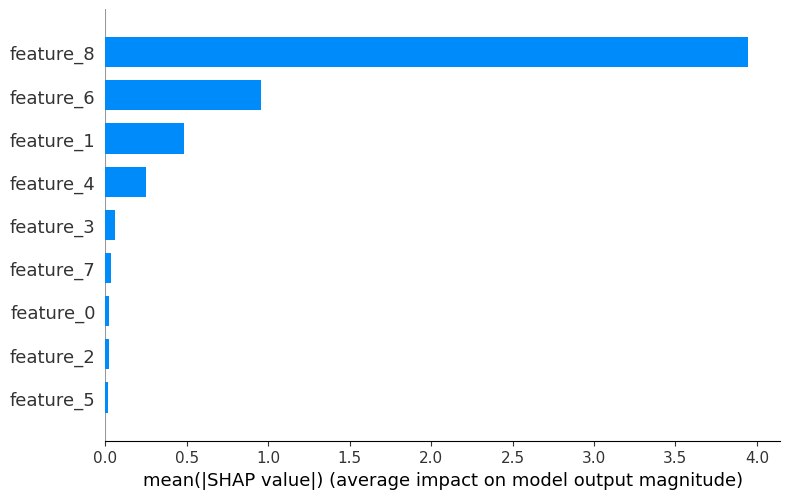

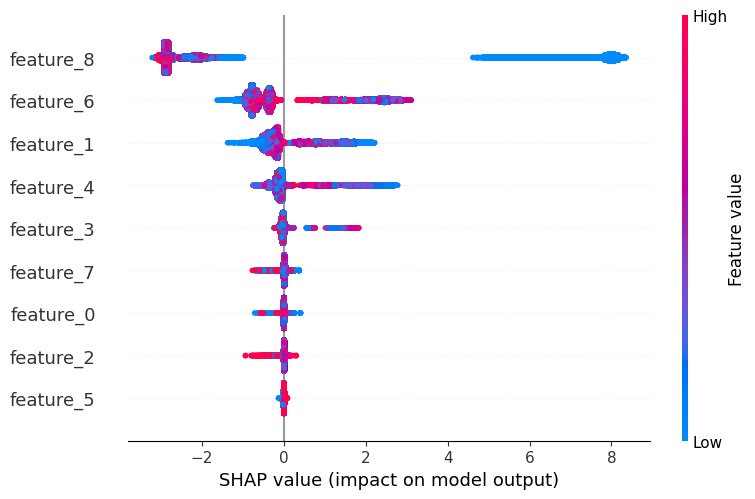

D:\Personal\KAIM-10 Academy\Week 5-6\Project\fraud-detection\venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


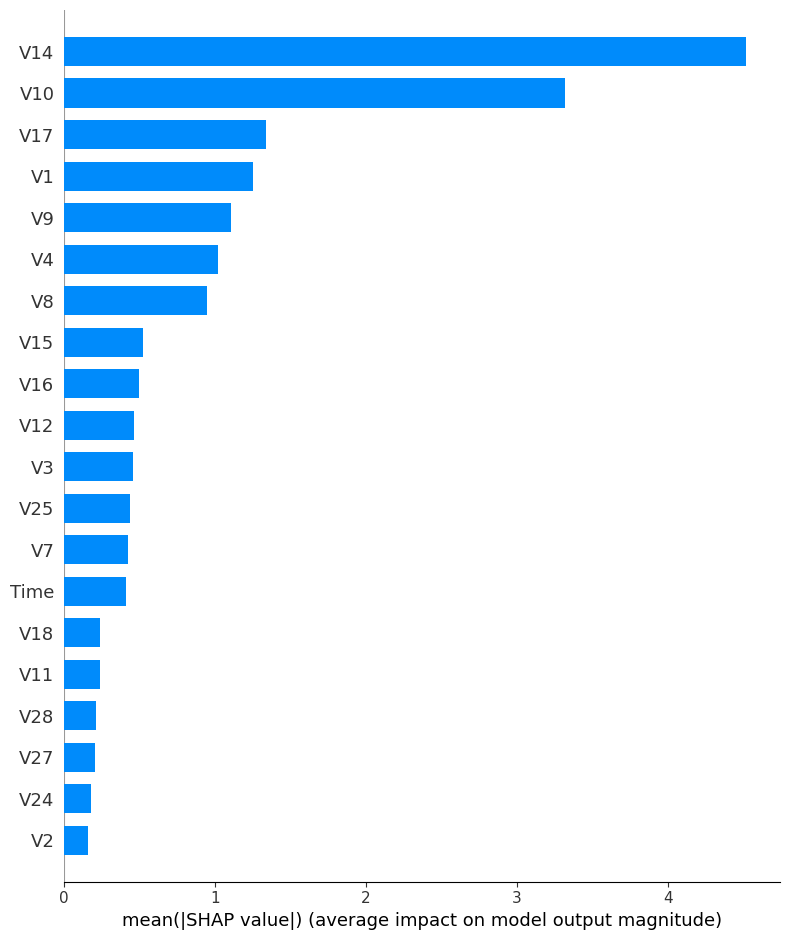

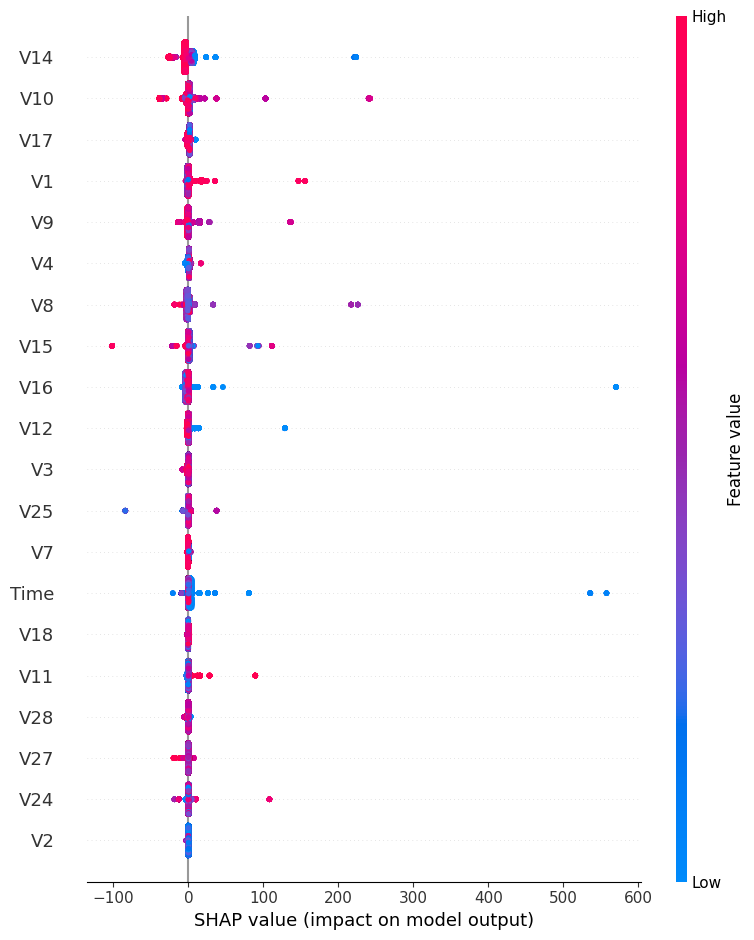

In [18]:

import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

# Import your Task 3 functions
from task3_model_explain import (
    get_model_feature_importance,
    compute_shap_values,
    get_tp_fp_fn_indices,
    plot_shap_force
)
# -----------------------------
# 2️⃣ SHAP Analysis - Summary Plot
# -----------------------------
# Initialize JS for plots
shap.initjs()

# Fraud Dataset
explainer_fraud, shap_values_fraud_pos = compute_shap_values(best_fraud_model, X_fraud_test)
shap.summary_plot(shap_values_fraud_pos, X_fraud_test, plot_type="bar")  # Top features bar plot
shap.summary_plot(shap_values_fraud_pos, X_fraud_test)  # Dot plot

# Creditcard Dataset
explainer_credit, shap_values_credit_pos = compute_shap_values(best_creditcard_model, X_credit_test)
shap.summary_plot(shap_values_credit_pos, X_credit_test, plot_type="bar")
shap.summary_plot(shap_values_credit_pos, X_credit_test)

SHAP Analysis - Generate SHAP Force Plots for at least 3 individual predictions:

In [22]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

# Import  Task 3 functions
from task3_model_explain import (
    get_model_feature_importance,
    compute_shap_values,
    get_tp_fp_fn_indices,
    plot_shap_force
)

# Initialize JS visualization for SHAP
shap.initjs()

# -----------------------------
# Predictions for Fraud dataset
# -----------------------------
y_pred_fraud = best_fraud_model.predict(X_fraud_test)
tp_idx, fp_idx, fn_idx = get_tp_fp_fn_indices(y_fraud_test.values, y_pred_fraud)

# -----------------------------
# Generate SHAP Force Plots
# -----------------------------

# True Positive
force_tp = plot_shap_force(explainer_fraud, shap_values_fraud_pos, X_fraud_test, tp_idx[0])
display(force_tp)
print("✅ True Positive Force Plot")

# False Positive
force_fp = plot_shap_force(explainer_fraud, shap_values_fraud_pos, X_fraud_test, fp_idx[0])
display(force_fp)
print("⚠️ False Positive Force Plot")

# False Negative
force_fn = plot_shap_force(explainer_fraud, shap_values_fraud_pos, X_fraud_test, fn_idx[0])
display(force_fn)
print("❌ False Negative Force Plot")

# For binary classifiers like LightGBM
# shap_values_credit_pos should be the positive class (fraudulent class)

if isinstance(shap_values_credit_pos, list):
    # Usually shap_values[1] is for class 1 (fraud)
    shap_values_credit_pos = shap_values_credit_pos[1]

# Then generate the force plots
from IPython.display import display

# True Positive
force_tp_c = plot_shap_force(explainer_credit, shap_values_credit_pos, X_credit_test, tp_idx_c[0])
display(force_tp_c)
print("Creditcard True Positive Force Plot ✅")

# False Positive
force_fp_c = plot_shap_force(explainer_credit, shap_values_credit_pos, X_credit_test, fp_idx_c[0])
display(force_fp_c)
print("Creditcard False Positive Force Plot ⚠️")

# False Negative
force_fn_c = plot_shap_force(explainer_credit, shap_values_credit_pos, X_credit_test, fn_idx_c[0])
display(force_fn_c)
print("Creditcard False Negative Force Plot ❌")


✅ True Positive Force Plot


⚠️ False Positive Force Plot


❌ False Negative Force Plot


Creditcard True Positive Force Plot ✅


Creditcard False Positive Force Plot ⚠️


Creditcard False Negative Force Plot ❌


In [23]:
import pandas as pd
import numpy as np

# -----------------------------
# Fraud Dataset
# -----------------------------
print("📌 Fraud Dataset Analysis\n")

# True Positive
tp_index = tp_idx[0]
shap_tp = shap_values_fraud_pos[tp_index]
features_tp = X_fraud_test.iloc[tp_index]

shap_df_tp = pd.DataFrame({
    "Feature": features_tp.index,
    "Feature_Value": features_tp.values,
    "SHAP_Value": shap_tp
}).sort_values(by="SHAP_Value", key=abs, ascending=False)
print("✅ True Positive (Fraud) - Top SHAP features:")
display(shap_df_tp.head(10))

# False Positive
fp_index = fp_idx[0]
shap_fp = shap_values_fraud_pos[fp_index]
features_fp = X_fraud_test.iloc[fp_index]

shap_df_fp = pd.DataFrame({
    "Feature": features_fp.index,
    "Feature_Value": features_fp.values,
    "SHAP_Value": shap_fp
}).sort_values(by="SHAP_Value", key=abs, ascending=False)
print("⚠️ False Positive (Fraud) - Top SHAP features:")
display(shap_df_fp.head(10))

# False Negative
fn_index = fn_idx[0]
shap_fn = shap_values_fraud_pos[fn_index]
features_fn = X_fraud_test.iloc[fn_index]

shap_df_fn = pd.DataFrame({
    "Feature": features_fn.index,
    "Feature_Value": features_fn.values,
    "SHAP_Value": shap_fn
}).sort_values(by="SHAP_Value", key=abs, ascending=False)
print("❌ False Negative (Fraud) - Top SHAP features:")
display(shap_df_fn.head(10))

# -----------------------------
# Creditcard Dataset
# -----------------------------
print("\n📌 Creditcard Dataset Analysis\n")

# True Positive
tp_index_c = tp_idx_c[0]
shap_tp_c = shap_values_credit_pos[tp_index_c]
features_tp_c = X_credit_test.iloc[tp_index_c]

shap_df_tp_c = pd.DataFrame({
    "Feature": features_tp_c.index,
    "Feature_Value": features_tp_c.values,
    "SHAP_Value": shap_tp_c
}).sort_values(by="SHAP_Value", key=abs, ascending=False)
print("✅ True Positive (Creditcard) - Top SHAP features:")
display(shap_df_tp_c.head(10))

# False Positive
fp_index_c = fp_idx_c[0]
shap_fp_c = shap_values_credit_pos[fp_index_c]
features_fp_c = X_credit_test.iloc[fp_index_c]

shap_df_fp_c = pd.DataFrame({
    "Feature": features_fp_c.index,
    "Feature_Value": features_fp_c.values,
    "SHAP_Value": shap_fp_c
}).sort_values(by="SHAP_Value", key=abs, ascending=False)
print("⚠️ False Positive (Creditcard) - Top SHAP features:")
display(shap_df_fp_c.head(10))

# False Negative
fn_index_c = fn_idx_c[0]
shap_fn_c = shap_values_credit_pos[fn_index_c]
features_fn_c = X_credit_test.iloc[fn_index_c]

shap_df_fn_c = pd.DataFrame({
    "Feature": features_fn_c.index,
    "Feature_Value": features_fn_c.values,
    "SHAP_Value": shap_fn_c
}).sort_values(by="SHAP_Value", key=abs, ascending=False)
print("❌ False Negative (Creditcard) - Top SHAP features:")
display(shap_df_fn_c.head(10))

📌 Fraud Dataset Analysis

✅ True Positive (Fraud) - Top SHAP features:


,Feature,Feature_Value,SHAP_Value
8,feature_8,-1.577617,7.996123
4,feature_4,1.128048,-0.183023
6,feature_6,2.304476,-0.173943
1,feature_1,-1.197169,-0.164095
0,feature_0,-1.723272,-0.102544
3,feature_3,1.114435,-0.013438
7,feature_7,0.375916,0.011340
2,feature_2,1.563005,-0.007311
5,feature_5,0.843495,0.003832


⚠️ False Positive (Fraud) - Top SHAP features:


,Feature,Feature_Value,SHAP_Value
8,feature_8,-1.576410,-1.044913
6,feature_6,-0.944649,-0.503629
1,feature_1,-0.596821,-0.142007
0,feature_0,1.639176,-0.052033
4,feature_4,-0.954341,-0.047361
3,feature_3,1.114435,-0.023340
7,feature_7,0.104272,0.016269
5,feature_5,-1.185544,-0.014837
2,feature_2,1.562804,-0.014800


❌ False Negative (Fraud) - Top SHAP features:


,Feature,Feature_Value,SHAP_Value
8,feature_8,-1.270518,-2.741624
6,feature_6,0.331793,-0.544917
1,feature_1,-0.323935,-0.392543
4,feature_4,-0.260211,-0.286768
3,feature_3,1.114435,-0.036006
0,feature_0,-1.216888,0.016764
7,feature_7,-0.320369,0.010499
2,feature_2,1.305753,0.005886
5,feature_5,0.843495,-0.000360



📌 Creditcard Dataset Analysis

✅ True Positive (Creditcard) - Top SHAP features:


,Feature,Feature_Value,SHAP_Value
14,V14,-11.470693,5.473149
17,V17,-21.047630,1.851779
10,V10,-13.074068,1.286767
15,V15,0.993143,-1.195574
27,V27,-0.817680,1.112871
4,V4,8.786257,1.066460
1,V1,-12.835760,-1.021319
8,V8,7.960521,-0.768380
7,V7,-14.248847,0.760687
9,V9,-7.718751,0.447481


⚠️ False Positive (Creditcard) - Top SHAP features:


,Feature,Feature_Value,SHAP_Value
14,V14,-1.156188,-2.539759
4,V4,2.713153,2.267501
17,V17,0.343463,2.000611
1,V1,1.108159,1.504502
9,V9,-0.493787,-1.466687
3,V3,0.326021,-1.127305
10,V10,0.222231,-1.045182
12,V12,0.590077,-1.000704
8,V8,0.143319,-0.605919
0,Time,-0.693013,0.416576


❌ False Negative (Creditcard) - Top SHAP features:


,Feature,Feature_Value,SHAP_Value
4,V4,-0.755458,-2.711432
17,V17,1.194212,2.206221
14,V14,-1.824839,-1.034457
3,V3,-1.192258,-0.982657
15,V15,-0.229679,0.584398
9,V9,-0.140927,-0.571480
10,V10,0.249311,-0.530690
27,V27,0.020182,0.490251
12,V12,-0.329759,-0.485857
8,V8,0.117200,-0.456702


3. Interpretation: Step 3A – Compare SHAP with Built-in Feature Importance

In [27]:
from task3_model_explain import get_top_shap_features

# -----------------------------
# Fraud Dataset
# -----------------------------
# Top 5 features according to SHAP
top_shap_fraud = get_top_shap_features(shap_values_fraud_pos, X_fraud_test, top_n=5)
print("Top 5 SHAP Features (Fraud Dataset):")
print(top_shap_fraud)

# Compare with built-in feature importance (from Step 1)
print("\nBuilt-in Feature Importance (Top 5):")
print(fi_fraud.head(5))

Top 5 SHAP Features (Fraud Dataset):
feature_8    3.945138
feature_6    0.955298
feature_1    0.482191
feature_4    0.245922
feature_3    0.059877
dtype: float64

Built-in Feature Importance (Top 5):
feature_6    1344
feature_1    1060
feature_8     181
feature_4     135
feature_7      76
dtype: int32


In [28]:
# -----------------------------
# Creditcard Dataset
# -----------------------------
top_shap_credit = get_top_shap_features(shap_values_credit_pos, X_credit_test, top_n=5)
print("Top 5 SHAP Features (Creditcard Dataset):")
print(top_shap_credit)

print("\nBuilt-in Feature Importance (Top 5):")
print(fi_credit.head(5))

Top 5 SHAP Features (Creditcard Dataset):
V14    4.514512
V10    3.316004
V17    1.338471
V1     1.253217
V9     1.103560
dtype: float64

Built-in Feature Importance (Top 5):
V4     216
V14    173
V18    128
V8     125
V26    122
dtype: int32


Step 3B – Identify Key Drivers of Fraud Predictions

In [29]:
print("📌 Fraud Dataset - Interpretation Notes:")
for feature in top_shap_fraud.index:
    if feature not in fi_fraud.index[:5]:
        print(f"- {feature}: High SHAP influence but not top built-in → may indicate non-linear or rare-event impact.")
    else:
        print(f"- {feature}: Confirmed important by both SHAP and built-in importance.")

📌 Fraud Dataset - Interpretation Notes:
- feature_8: Confirmed important by both SHAP and built-in importance.
- feature_6: Confirmed important by both SHAP and built-in importance.
- feature_1: Confirmed important by both SHAP and built-in importance.
- feature_4: Confirmed important by both SHAP and built-in importance.
- feature_3: High SHAP influence but not top built-in → may indicate non-linear or rare-event impact.


In [30]:
print("\n📌 Creditcard Dataset - Interpretation Notes:")
for feature in top_shap_credit.index:
    if feature not in fi_credit.index[:5]:
        print(f"- {feature}: High SHAP influence but not top built-in → may indicate non-linear or rare-event impact.")
    else:
        print(f"- {feature}: Confirmed important by both SHAP and built-in importance.")


📌 Creditcard Dataset - Interpretation Notes:
- V14: Confirmed important by both SHAP and built-in importance.
- V10: High SHAP influence but not top built-in → may indicate non-linear or rare-event impact.
- V17: High SHAP influence but not top built-in → may indicate non-linear or rare-event impact.
- V1: High SHAP influence but not top built-in → may indicate non-linear or rare-event impact.
- V9: High SHAP influence but not top built-in → may indicate non-linear or rare-event impact.


Step 3C – Surprising or Counterintuitive Findings

# 🔍 Step 3 – Model Interpretation

## 📌 Fraud Dataset

**Top SHAP Features (Drivers of Fraud):**  
`feature_8`, `feature_6`, `feature_1`, `feature_4`, `feature_3`

**Top Built-in Features:**  
`feature_6`, `feature_1`, `feature_8`, `feature_4`, `feature_7`

**Observations:**
- ✅ **Confirmed Drivers:** `feature_8`, `feature_6`, `feature_1`, `feature_4` → appear in both SHAP & built-in top 5 → **strong, consistent predictors**
- ⚡ **Unique SHAP Driver:** `feature_3` → highly influential in SHAP but not in built-in → may indicate **non-linear interactions or rare-event impact**

**Interpretation:**  
Most important features are consistent across methods. SHAP reveals subtle drivers (`feature_3`) that might be critical in certain fraud scenarios.

---

## 📌 Creditcard Dataset

**Top SHAP Features:**  
`V14`, `V10`, `V17`, `V1`, `V9`

**Top Built-in Features:**  
`V4`, `V14`, `V18`, `V8`, `V26`

**Observations:**
- ✅ **Confirmed Driver:** `V14` → consistent predictor in both SHAP & built-in top 5  
- ⚡ **Unique SHAP Drivers:** `V10`, `V17`, `V1`, `V9` → highly influential according to SHAP but not in built-in → likely **non-linear patterns or rare-event transactions**

**Interpretation:**  
SHAP uncovers additional drivers that traditional feature importance misses. These may represent complex patterns critical for fraud detection.

---

## 🔑 Key Takeaways

1. SHAP uncovers **hidden drivers** that traditional feature importance can overlook.  
2. Features confirmed by both methods → reliable **core predictors**.  
3. Unique SHAP drivers → likely **non-linear or rare-event signals**, critical for nuanced fraud detection.

4.	Business Recommendations

4.1. Provide at least 3 actionable recommendations based on your analysis

In [33]:
print("📌 Step 4 – Business Recommendations\n")

print("1️⃣ Focus on Core Drivers:")
print("- Fraud Dataset: feature_8, feature_6, feature_1 strongly influence fraud predictions.")
print("- Creditcard Dataset: V14 is the most influential.")
print("- Action: Transactions with extreme values in these features should trigger additional verification or manual review.\n")

print("2️⃣ Capture Non-linear / Rare-event Patterns:")
print("- Fraud Dataset: feature_3 | Creditcard Dataset: V10, V17, V1, V9 are high SHAP but low built-in importance.")
print("- Action: Set dynamic alerts for unusual or rare transaction patterns to catch edge-case fraud events.\n")

print("3️⃣ Temporal / Behavioral Checks:")
print("- Observed SHAP patterns suggest timing or behavioral features affect fraud probability.")
print("- Example Action: Transactions within 24 hours of account signup should receive additional verification.")
print("- Example Action: Multiple transactions within 1 hour should trigger alerts.\n")

print("4️⃣ Periodic Model Review & Feedback Loop:")
print("- Fraud patterns evolve over time; features that were minor can become significant.")
print("- Action: Monitor SHAP value changes, retrain models periodically, and update alert rules accordingly.\n")

📌 Step 4 – Business Recommendations

1️⃣ Focus on Core Drivers:
- Fraud Dataset: feature_8, feature_6, feature_1 strongly influence fraud predictions.
- Creditcard Dataset: V14 is the most influential.
- Action: Transactions with extreme values in these features should trigger additional verification or manual review.

2️⃣ Capture Non-linear / Rare-event Patterns:
- Fraud Dataset: feature_3 | Creditcard Dataset: V10, V17, V1, V9 are high SHAP but low built-in importance.
- Action: Set dynamic alerts for unusual or rare transaction patterns to catch edge-case fraud events.

3️⃣ Temporal / Behavioral Checks:
- Observed SHAP patterns suggest timing or behavioral features affect fraud probability.
- Example Action: Transactions within 24 hours of account signup should receive additional verification.
- Example Action: Multiple transactions within 1 hour should trigger alerts.

4️⃣ Periodic Model Review & Feedback Loop:
- Fraud patterns evolve over time; features that were minor can become 